In [1]:
DIRECTORY = "tmp/"


In [2]:
import os

logfiles = []

for folder in os.listdir(DIRECTORY):
    for file in os.listdir(os.path.join(DIRECTORY, folder)):
        if file.endswith(".log"):
            log_file_path = os.path.join(DIRECTORY, folder, file)
            logfiles.append(log_file_path)

logfiles

['tmp/4jcb0dbjyy/train.log',
 'tmp/wnwjbxmd0t/train.log',
 'tmp/u9aczfm6zj/train.log',
 'tmp/6gk8vnoyet/train.log',
 'tmp/hplu3s9t0d/train.log',
 'tmp/y4okbddeqo/train.log',
 'tmp/6r286eswe4/train.log',
 'tmp/jcmlb6nij9/train.log',
 'tmp/rub43ift2f/train.log',
 'tmp/vyobcoz7cl/train.log']

In [3]:
import re

def get_params(log_file_path):
    with open(log_file_path, 'r') as log_file:
        log_data = log_file.read()
    pattern = re.compile(r'(\w+):\s*(.+)')

    params = {}
    for match in pattern.finditer(log_data):
        key, value = match.groups()
        
        # If the value can be interpreted as a number (int or float), convert it
        if value.lower() in ['true', 'false']:
            value = value.lower() == 'true'
        elif re.match(r'^\d+(\.\d+)?$', value):  # If the value is a number (integer or float)
            value = float(value) if '.' in value else int(value)
        
        # Add to the dictionary
        params[key] = value
    return params


In [12]:
import re
import json

def get_training_testing_steps(log_file_path):
    training_steps = []
    testing_steps = []

    log_pattern = re.compile(r'__log:\{(.*?)\}')  # Matches everything between __log:{...}

    with open(log_file_path, 'r') as log_file:
        for line in log_file:
            match = log_pattern.search(line)
            if match:
                log_data = match.group(1) 
                try:
                    log_json = json.loads('{' + log_data + '}')
                    if 'train_acc' in log_json:  # This indicates a training step
                        training_steps.append(log_json)
                    elif 'test_acc_ema' in log_json:  # This indicates a testing step
                        testing_steps.append(log_json)
                except json.JSONDecodeError:
                    print(f"Error decoding JSON in line: {line.strip()}")

    return training_steps, testing_steps

log_file_path = 'tmp/6gk8vnoyet/train.log'
training_steps, testing_steps = get_training_testing_steps(log_file_path)
print(training_steps)

[{'nb_steps': 20, 'train_acc': 0.17161747699930427, 'loss': 2.2396337196302545, 'grad_sample_gradients_norms': 11.671040291619823, 'grad_sample_gradients_norms_lowerC': 0.0}, {'nb_steps': 40, 'train_acc': 0.24914960413094583, 'loss': 2.1085805913369433, 'grad_sample_gradients_norms': 10.865665763428831, 'grad_sample_gradients_norms_lowerC': 0.0}, {'nb_steps': 60, 'train_acc': 0.2582674895595204, 'loss': 2.10630708607797, 'grad_sample_gradients_norms': 11.297015499481978, 'grad_sample_gradients_norms_lowerC': 0.0005744925315970893}, {'nb_steps': 80, 'train_acc': 0.33291058995238887, 'loss': 1.8896698056881156, 'grad_sample_gradients_norms': 10.187074867046833, 'grad_sample_gradients_norms_lowerC': 0.0015794669299111549}, {'nb_steps': 100, 'train_acc': 0.36264116908783656, 'loss': 1.8224159106375553, 'grad_sample_gradients_norms': 11.197723247030538, 'grad_sample_gradients_norms_lowerC': 0.0027944111776447107}, {'nb_steps': 120, 'train_acc': 0.3863216232019323, 'loss': 1.7899618212447161

In [ ]:
log_file_path = 'tmp/6gk8vnoyet/train.log'
experiment1 = get_params(log_file_path)
training_steps, testing_steps = get_training_testing_steps(log_file_path)
experiment1["training_steps"] = training_steps
experiment1["testing_steps"] = testing_steps
experiment1

In [23]:
experiments = []
for log_file_path in logfiles:
    exp = get_params(log_file_path)
    training_steps, testing_steps = get_training_testing_steps(log_file_path)
    exp["training_steps"] = training_steps
    exp["testing_steps"] = testing_steps
    experiments.append(exp)

In [41]:
import pandas as pd
df_experiments = pd.DataFrame(experiments)
df_experiments.columns

Index(['00', 'WRN_k', 'batch_size', 'command', 'data_root', 'debug_slurm',
       'delta', 'dump_path', 'exp_id', 'exp_name', 'experiment', 'freq_log',
       'freq_log_val', 'global_rank', 'init', 'is_master', 'is_slurm_job',
       'local_rank', 'lr', 'master_port', 'max_per_sample_grad_norm',
       'max_physical_batch_size', 'momentum', 'multi_gpu', 'multi_node',
       'n_gpu_per_node', 'n_nodes', 'nb_groups', 'node_id', 'order1', 'order2',
       'poisson_sampling', 'proportion', 'ref_B', 'ref_nb_steps', 'ref_noise',
       'transform', 'world_size', '01', 'training_steps', 'testing_steps',
       '14', '15', '06', '07', '08', '09', '03', '04', '05', '02', '10', '11',
       '12', '13'],
      dtype='object')

In [62]:
df_experiments["training_steps"][1]

[{'nb_steps': 20,
  'train_acc': 0.1561626843420882,
  'loss': 2.3480286188597246,
  'grad_sample_gradients_norms': 13.039952330017682,
  'grad_sample_gradients_norms_lowerC': 0.0},
 {'nb_steps': 40,
  'train_acc': 0.22247628258596844,
  'loss': 2.2550623455608902,
  'grad_sample_gradients_norms': 12.259728592003734,
  'grad_sample_gradients_norms_lowerC': 0.0},
 {'nb_steps': 60,
  'train_acc': 0.2740138141191607,
  'loss': 2.0366034922741654,
  'grad_sample_gradients_norms': 11.555162973164764,
  'grad_sample_gradients_norms_lowerC': 0.00039184952978056425}]

## Experiments about the Added Noise

In [42]:
df_noise_experiments = df_experiments[df_experiments.ref_nb_steps == 500]
df_noise_experiments

,00,WRN_k,batch_size,command,data_root,debug_slurm,delta,dump_path,exp_id,exp_name,...,08,09,03,04,05,02,10,11,12,13
1,NaN,4,256,python cifar10.py --batch_size 256 --ref_nb_st...,data,False,1e-05,/tmp/wnwjbxmd0t,wnwjbxmd0t,bypass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,4,256,python cifar10.py --batch_size 256 --ref_nb_st...,data,False,1e-05,/tmp/u9aczfm6zj,u9aczfm6zj,bypass,...,"58:55 - 2:08:24 - __log:{""nb_steps"": 380, ""tra...","42:58 - 2:52:27 - __log:{""final_train_acc_non_...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,4,256,python cifar10.py --batch_size 256 --ref_nb_st...,data,False,1e-05,/tmp/6gk8vnoyet,6gk8vnoyet,bypass,...,NaN,NaN,57:51 - 0:00:00 - Running command: python cifa...,"58:33 - 1:00:42 - __log:{""nb_steps"": 180, ""tra...","59:57 - 2:02:06 - __log:{""nb_steps"": 360, ""tra...",NaN,NaN,NaN,NaN,NaN
5,NaN,4,256,python cifar10.py --batch_size 256 --ref_nb_st...,data,False,1e-05,/tmp/y4okbddeqo,y4okbddeqo,bypass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"55:06 - 0:19:57 - __log:{""nb_steps"": 60, ""trai...","56:39 - 1:21:30 - __log:{""final_train_acc_non_..."
6,NaN,4,256,python cifar10.py --batch_size 256 --ref_nb_st...,data,False,1e-05,/tmp/6r286eswe4,6r286eswe4,bypass,...,NaN,"56:20 - 0:13:17 - __log:{""nb_steps"": 40, ""trai...",NaN,NaN,NaN,NaN,"57:31 - 1:14:27 - __log:{""nb_steps"": 220, ""tra...","59:16 - 2:16:12 - __log:{""test_acc_ema"": 0.613...","35:03 - 2:51:59 - __log:{""final_train_acc_non_...",NaN
8,NaN,4,256,python cifar10.py --batch_size 256 --ref_nb_st...,data,False,1e-05,/tmp/rub43ift2f,rub43ift2f,bypass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"58:56 - 0:02:14 - __log:{""nb_steps"": 20, ""trai..."


In [43]:
df_noise_experiments["ref_noise"]

1    1.0
2    3.0
3    3.0
5    1.0
6    3.0
8    1.0
Name: ref_noise, dtype: float64

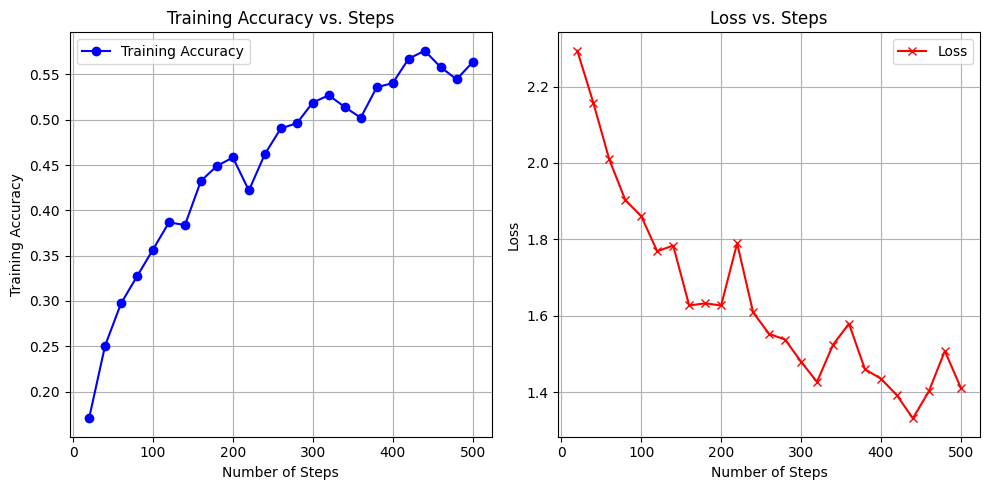

In [ ]:
import matplotlib.pyplot as plt

experiment_idx = 1
data = df_noise_experiments.iloc[experiment_idx]["training_steps"]

# Extracting values for plotting
steps = [entry['nb_steps'] for entry in data]
train_acc = [entry['train_acc'] for entry in data]
loss = [entry['loss'] for entry in data]

# Create the plot
plt.figure(figsize=(10, 5))

# Plot training accuracy
plt.subplot(1, 2, 1)
plt.plot(steps, train_acc, label='Training Accuracy', color='b', marker='o')
plt.xlabel('Number of Steps')
plt.ylabel('Training Accuracy')
plt.title('Training Accuracy vs. Steps')
plt.grid(True)
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(steps, loss, label='Loss', color='r', marker='x')
plt.xlabel('Number of Steps')
plt.ylabel('Loss')
plt.title('Loss vs. Steps')
plt.grid(True)
plt.legend()

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()


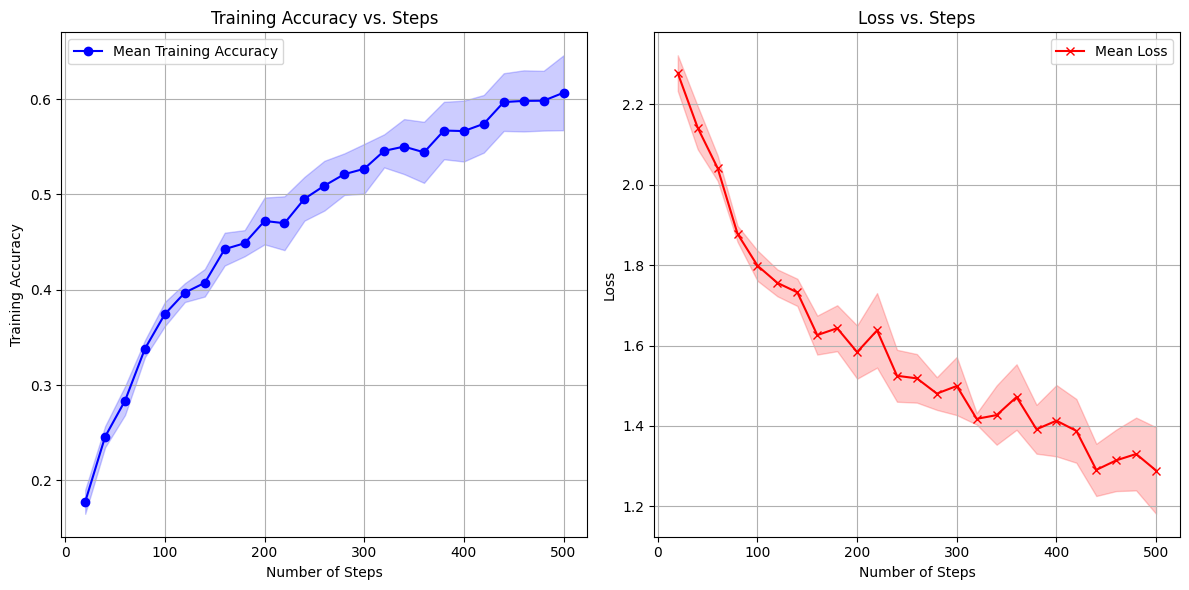

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# Initialize lists to store training accuracy and loss at each step
all_steps = []
all_train_acc = {}
all_loss = {}

# Loop through all experiments
for idx in range(len(df_noise_experiments)):

    experiment = df_noise_experiments.iloc[idx]
    training_steps = experiment["training_steps"]
    
    # Extract steps, train_acc, and loss for each experiment
    steps = [entry['nb_steps'] for entry in training_steps]
    train_acc = [entry['train_acc'] for entry in training_steps]
    loss = [entry['loss'] for entry in training_steps]
    
    # For each unique step, accumulate the train_acc and loss values
    for step, acc, l in zip(steps, train_acc, loss):
        if step not in all_steps:
            all_steps.append(step)
        
        if step not in all_train_acc:
            all_train_acc[step] = []
        if step not in all_loss:
            all_loss[step] = []
        
        all_train_acc[step].append(acc)
        all_loss[step].append(l)

# Sort the steps (optional, depending on how the steps are ordered)
all_steps = sorted(all_steps)

# Calculate the mean and standard deviation for each step
mean_train_acc = []
std_train_acc = []
mean_loss = []
std_loss = []

for step in all_steps:
    mean_train_acc.append(np.mean(all_train_acc[step]))
    std_train_acc.append(np.std(all_train_acc[step]))
    mean_loss.append(np.mean(all_loss[step]))
    std_loss.append(np.std(all_loss[step]))

# Create the plot
plt.figure(figsize=(12, 6))

# Plot training accuracy
plt.subplot(1, 2, 1)
plt.plot(all_steps, mean_train_acc, label='Mean Training Accuracy', color='b', marker='o')
plt.fill_between(all_steps, np.array(mean_train_acc) - np.array(std_train_acc), 
                 np.array(mean_train_acc) + np.array(std_train_acc), color='b', alpha=0.2)
plt.xlabel('Number of Steps')
plt.ylabel('Training Accuracy')
plt.title('Training Accuracy vs. Steps')
plt.grid(True)
plt.legend()

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(all_steps, mean_loss, label='Mean Loss', color='r', marker='x')
plt.fill_between(all_steps, np.array(mean_loss) - np.array(std_loss), 
                 np.array(mean_loss) + np.array(std_loss), color='r', alpha=0.2)
plt.xlabel('Number of Steps')
plt.ylabel('Loss')
plt.title('Loss vs. Steps')
plt.grid(True)
plt.legend()

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()


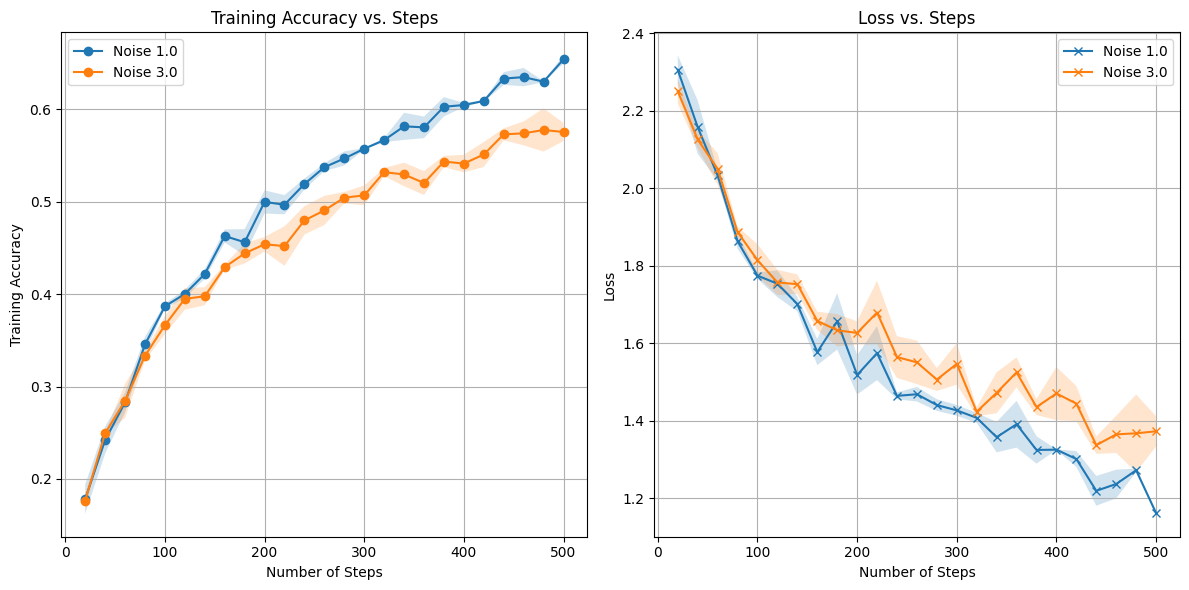

In [70]:
import matplotlib.pyplot as plt
import numpy as np

# Initialize lists to store training accuracy and loss at each step, grouped by ref_noise
all_steps = []
all_train_acc = {}
all_loss = {}
ref_noise_groups = {}

# Loop through all experiments
for idx in range(len(df_noise_experiments)):

    experiment = df_noise_experiments.iloc[idx]
    ref_noise = experiment["ref_noise"]
    training_steps = experiment["training_steps"]
    
    # Extract steps, train_acc, and loss for each experiment
    steps = [entry['nb_steps'] for entry in training_steps]
    train_acc = [entry['train_acc'] for entry in training_steps]
    loss = [entry['loss'] for entry in training_steps]
    
    # For each unique step, accumulate the train_acc and loss values grouped by ref_noise
    for step, acc, l in zip(steps, train_acc, loss):
        if step not in all_steps:
            all_steps.append(step)
        
        if ref_noise not in ref_noise_groups:
            ref_noise_groups[ref_noise] = {"train_acc": {}, "loss": {}}
        
        if step not in ref_noise_groups[ref_noise]["train_acc"]:
            ref_noise_groups[ref_noise]["train_acc"][step] = []
        if step not in ref_noise_groups[ref_noise]["loss"]:
            ref_noise_groups[ref_noise]["loss"][step] = []
        
        ref_noise_groups[ref_noise]["train_acc"][step].append(acc)
        ref_noise_groups[ref_noise]["loss"][step].append(l)

# Sort the steps (optional, depending on how the steps are ordered)
all_steps = sorted(all_steps)

# Create the plot
plt.figure(figsize=(12, 6))

# Loop through each ref_noise group and calculate mean and std, then plot
for ref_noise, group in ref_noise_groups.items():
    mean_train_acc = []
    std_train_acc = []
    mean_loss = []
    std_loss = []
    
    # Calculate the mean and standard deviation for each step in this group
    for step in all_steps:
        mean_train_acc.append(np.mean(group["train_acc"].get(step, [0])))
        std_train_acc.append(np.std(group["train_acc"].get(step, [0])))
        mean_loss.append(np.mean(group["loss"].get(step, [0])))
        std_loss.append(np.std(group["loss"].get(step, [0])))
    
    # Plot training accuracy with shaded standard deviation
    plt.subplot(1, 2, 1)
    plt.plot(all_steps, mean_train_acc, label=f'Noise {ref_noise}', marker='o')
    plt.fill_between(all_steps, np.array(mean_train_acc) - np.array(std_train_acc), 
                     np.array(mean_train_acc) + np.array(std_train_acc), alpha=0.2)
    
    # Plot loss with shaded standard deviation
    plt.subplot(1, 2, 2)
    plt.plot(all_steps, mean_loss, label=f'Noise {ref_noise}', marker='x')
    plt.fill_between(all_steps, np.array(mean_loss) - np.array(std_loss), 
                     np.array(mean_loss) + np.array(std_loss), alpha=0.2)

# Set labels, titles, and grids
plt.subplot(1, 2, 1)
plt.xlabel('Number of Steps')
plt.ylabel('Training Accuracy')
plt.title('Training Accuracy vs. Steps')
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.xlabel('Number of Steps')
plt.ylabel('Loss')
plt.title('Loss vs. Steps')
plt.grid(True)
plt.legend()

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the plot
plt.show()
